# A Reinforcement Learning Approach to Quixx: A Fast Family Dice Game

This project connects technical work and deep machine learning to a real-world context through Quixx. Quixx is a dice game that is a great fit for a reinforcement learning model because it has clear states (scorecards for each player), stochasticity (dice rolls), sequential decisions, and a clear objective (maximize the final score).

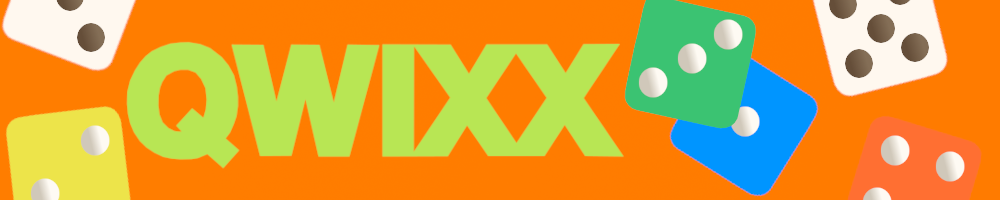

## Table of Contents

1. Problem and Context
- 1a. Problem Definition
- 1b. Motivation
- 1c. Question

2. Executive Summary

3. Data and Methodology
- 3a. Game Rules and Environment Framework
- 3b. Deep Learning Justification
- 3c. Limitations

4. Analysis
- 4a. Q-Learning
- 4b. Multi-Agent Monte Carlo Tree Search
- 4c. Random Baseline
- 4d. Deep Q-Learning (DQN)

5. Results
- 5a. Model Comparison
- 5b. Next Steps

## 1. Problem and Context

### 1a. Problem Definition

Quixx is a fast-paced, family dice game (2-5 players, ages 8+) that has sold millions of copies and is a staple at family game nights. My in-laws are very passionate about Quixx. On every turn, the active player rolls two white dice and four colored dice (red, yellow, green, blue). All players may immediately cross off the sum of the two white dice in any one of their four colored rows - provided the number appears to the right of the last mark already made in that row. The active player receives an extra option; they may also cross off the sum of one white die and one colored die in the matching colored row. Numbers must always be marked from left to right (red/yellow ascending 2-12; green/blue descending 12-2). If the active player chooses to cross off both the white dice sum and one combination of a white die and colored die, they must do so in that order (white sum first). The active player must cross off a box on their scorecard or take a penalty. A row can be "locked" once its final number is crossed off (removing that colored die from future rolls). The game ends as soon as two rows are locked or any player fills all four penalty boxes. Taking a penalty results in a score of -5 per penalty, and players' scores grow quadratically as the number of X's in any given row increase. The final score for a player can be defined as a function:

---

#### Qwixx Scoring Function
The score for a row with \(n\) crosses follows a triangular number pattern:

$$
S(n) = \frac{n(n+1)}{2}
$$

#### Total Score Formula
Let:
- \(r, y, g, b\) = number of crosses in each row (red, yellow, green, blue)
- \(p\) = number of penalties

$$
\text{Score} = S(r) + S(y) + S(g) + S(b) - 5p
$$

#### Example
If:
- Red = 3 → \(S(3) = 6\)
- Yellow = 0 → \(S(0) = 0\)
- Blue = 6 → \(S(6) = 21\)
- Green = 8 → \(S(8) = 36\)
- Penalties = 0

$$
\text{Score} = 6 + 0 + 21 + 36 - 0 = 63
$$

---

The core challenge is that every decision is stochastic (random dice) yet highly constrained. Players must weigh immediate opportunities against future row-completion potential, lock timing, and the fact that the opponents' dice rollws indirectly affect which dice remain available. Human players typically rely on rough heuristics (not skipping more than 3 or 4 boxes, avoiding taking penalties early), but it is unclear whether these are actually optimal strategies. Because the game is zero-sum in outcome (highest score wins) yet every player acts on every roll, discovering a superior strategy is a complicated problem.

### 1b. Motivation

Beyond personal curiosity (I usually never win), Quixx is an ideal example of real-world sequential decision-making under uncertainty. There is the idea of resource allocation (which rows to 'invest' in), risk management (when to take penalties), and multi-agent interaction. The same structure can be found in organizations with inventory management, balancing investment portfolios, and more. A reinforcement-learning approach ideally demonstrates how we can extract human-interpretable strategies from a hobby and generalize the approach to other domains or ideal gameplay. Essentially, I want to win more.

### 1c. Question

Can reinforcement learning - specifically Deep Q-Learning and a zero-sum Monte Carlo Tree Search (MCTS) - discover and compare optimal policies for Quixx? What concrete strategic insights do these policies reveal that human play might miss?

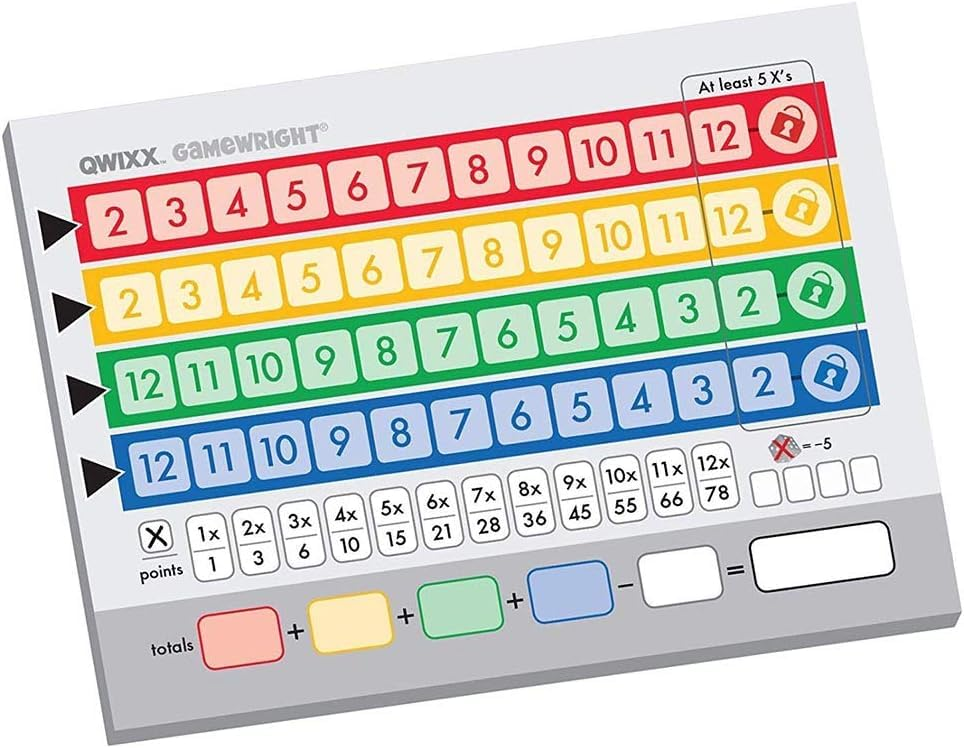

---

## 2. Executive Summary

Text here when done

---

## 3. Data and Methodology

### 3a. Game Rules and Environment Framework

This project does not use an external dataset, instead it creates its own data by implementing the rules of Quixx in Python. The codebase consists of two core modules I wrote:

`quixx_game.py` contains the game logic, including the dice, scorecard, game states, and order of legal turns.

`quixx_env.py` is a Gymnasium-compatible environment that converts the game state into action spaces for reinforcement learning.

The simulation mirrors the game, including random elements like dice rolls and constraints for marking X's sequentially and order of play. Reinforcement learning requires millions of iterations, and while supervised learning and gameplay data is very helpful for refining solutions to problems like AlphaGo, no such data exists for Quixx. So, simulation is the easiest solution.

The state-action-reward structure includes a flattened vector of both players' scorecards (4 rows * 11 possible marks + lock flags + penalties), current dice values, whose turn it is, and locked rows. The action space includes a discrete set of legal moves (e.g. mark white-sum in red row 5, mark white+red in red row 7, take penalty, or pass if you are not the active player). This prevents agents from taking illegal moves.

### 3b. Deep Learning Justification

Deep learning is appropriate because Quixx is a classic Markov Decision Process with stochastic transitions, sequential dependencies, and a clear reward (score). Neural networks excel at generalizing across the large but structured state space (given enough time and computation to train). The project compares a couple different RL approaches. I used a Stanford CS234 lecture on Monte Carlo Tree Search by Emma Brunskill to learn more about multi-agent learning in competitive contexts. I also used *Mastering the game of Go with deep neural networks and tree search* published in the journal Nature in 2016 as a source to better understand self-play reinforcement learning.

### 3c. Limitations

The state space for this game is an almost uncountable number of potential scorecard configurations, so tabular Q-Learning will use a dictionary; Deep Q-Learning may still be needed to fully scale the model and get accurate interpretable policies.

The simulation is assuming that agents and opponents are rational, adhere to the rules, and do not model human errors or other psychological factors that contribute to a group game.

Another very large limitation is the time I have to train these models, and the computational cost of training these models. As MCTS depth grows, so does the cost of training it.

---

## 4. Analysis

### 4a. Q-Learning

In `quixx_env.py`, the Q-learning agent is always Player 0. The environment treats Q-learning as a single agent RL (although Quixx is multiplayer typically). Turns within `env.step(action)` work as follows: When the agent (Player 0) is active, it chooses its action in the Q-table. The environment applies the agent's choice and if the agent marks nothing, it takes a penalty. This is the decision Q-Learning makes. When the opponent (Player 1) is active, the agent (inactive player) gets an opportunity to use the white sum. In this case, because Quixx is a two player game, the second player makes random legal moves.

Essentially, these are the main decisions the bot will learn:
- On active-player turns: Choose any legal combination of the dice (white-sum only, colored combo only, both with white first, or neither = penalty).
- On inactive player turns: Choose yes or no on the white-sum only.

#### Reward System and Justification:

Because Quixx scoring is non-linear (1 mark = 1 pt, 2 marks = 3 pts, ... 11 marks = 66 pts), a late-row mark is worth more than an early one. Fixed bonuses for simply marking a square ignore this completely, and the agent can learn to just be 'busy' while having bad strategy. The reward for an action is new_score - old_score. This encourages moves that improve score more.

The current reward system in `quixx_env.py` is:
- +(new_score - old_score) for the immediate score gained during the turn
- +0.1 if the agent successfully makes at least one legal move
- penalties are reflected naturally through the score difference
- +final)score * 0.05 as a small terminal reward when the game ends

This system should align the reinforcement signal with the true objective of Quixx (maximizing the final score) and accounts for the non-linear triangular scoring of each row.




In [1]:
# Install & imports
# !pip install gymnasium
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

# Import game files
from quixx_game import QuixxGame, Color
from quixx_env import QuixxEnv

Saving quixx_env.py to quixx_env.py
Saving quixx_game.py to quixx_game.py


In this section, I initialize a Q-learning agent to learn how to play Quixx. Because the state space is extremely large, I store Q-values in a dictionary where each state is converted into a hashable key using the function get_state_key(obs). This allows us to map each observed game state to a matrix of Q-values corresponding to possible actions.

The observation space is a 58-dimensional vector with 48 entries for the agent's scorecard, a value for the number of agent penalties, a value for number of opponent penalties, an entry for number of locked rows, an entry for whether the agent is active, and six entries for the six dice.

In [3]:
# Initialize the environment
env = QuixxEnv()

# Observation and action spaces
obs_space = env.observation_space
action_space = env.action_space

print("Observation space:", obs_space)
print("Action space:", action_space) # MultiDiscrete([5,9]) for white_choice + second_choice

Observation space: Box(0, [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 4 4 4 1 6 6 6 6 6 6], (58,), int8)
Action space: MultiDiscrete([5 9])


The hyperparameters in this cell tune how the agent learns, where **alpha** controls the learning rate and how quickly the agent updates its knowledge, **gamma** controls how much the agent values future rewards compared to immediate rewards, **epsilon** is the probability of choosing a random action instead of the best-known action, **min_epsilon** is the lowest value epsilon can decay to, and **decay_rate** is how quickly epsilon decays.

The agent has to balance two strategies: exploration and exploitation. Exploration involves trying random actions, which helps to discover new strategies and is controlled by **epsilon** while exploitation chooses the best known action using np.argmax(q_values), focusing on maximizing reward. After each step, the Q-value is updated using:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma \max Q(s',a') - Q(s,a) \right)
$$

Where **s** is the current state, **a** is the action taken, **r** is the reward received, and **s'** is the next state. This moves the current estimate toward a better estimate and incorporates the ideas of immediate rewards and expected future rewards.

In [ ]:
# Q-table initialization
# Because state space is large, use a dictionary (state_key → Q-values)
Q = {}  # key = tuple(obs), value = 5x9 numpy array of Q-values

def get_state_key(obs):
    return tuple(obs.tolist()) # hashable for dict

# Hyperparameters
alpha = 0.1 # Learning rate
gamma = 0.99 # Discount factor, how much do we value future outcomes?
epsilon = 1.0 # Exploration rate
min_epsilon = 0.01 # Minimum epsilon value
decay_rate = 0.0005 # Linear decay

# Helper functions
def choose_action(obs):
    state_key = get_state_key(obs)
    if state_key not in Q:
        Q[state_key] = np.zeros((5, 9)) # match action dimensions

    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Exploration
    else:
        q_values = Q[state_key]
        flat_idx = np.argmax(q_values)
        return np.unravel_index(flat_idx, (5, 9)) # Exploitation

def update_q_table(obs, action, reward, new_obs):
    state_key = get_state_key(obs)
    new_state_key = get_state_key(new_obs)

    if state_key not in Q:
        Q[state_key] = np.zeros((5, 9))
    if new_state_key not in Q:
        Q[new_state_key] = np.zeros((5, 9))

    # Q-update
    current_q = Q[state_key][action[0]][action[1]]
    max_future_q = np.max(Q[new_state_key])
    Q[state_key][action[0]][action[1]] = current_q + alpha * (reward + gamma * max_future_q - current_q)

This cell runs the Q-learning algorithm over many simulated episodes so the agent can ideally learn an effective strategy. The agent plays a specified number of games (specified by `episodes` variable), and at the start of each episode, the game is reset to an initial state. At each step, the agent chooses an action, takes a step in the environment to apply the action, updates the q-table, moves to the next state, and tracks the total reward.

In [ ]:
# Training loop
rewards = []
episodes = 1_000_000

for episode in range(episodes):
    obs, _ = env.reset()
    done = False
    total_reward = 0

    while not done: # The while loop plays until we reach completion
        action = choose_action(obs)
        new_obs, reward, done, _, info = env.step(action) # Given that action, take a step, update q-table, establish new state, and reward
        update_q_table(obs, action, reward, new_obs)
        obs = new_obs
        total_reward += reward

    rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon - decay_rate) # Take the max of either min epsilon or epsilon minus decay rate

    if episode % 50_000 == 0:
        print(f"Episode {episode} | Avg reward over last 100 games: {np.mean(rewards[-100:]):.2f}")

print("Training finished.\n")

Episode 0 | Avg reward over last 100 games: -19.85
Episode 50000 | Avg reward over last 100 games: -19.07
Episode 100000 | Avg reward over last 100 games: -18.79
Episode 150000 | Avg reward over last 100 games: -18.68
Episode 200000 | Avg reward over last 100 games: -18.60
Episode 250000 | Avg reward over last 100 games: -18.51
Episode 300000 | Avg reward over last 100 games: -18.23
Episode 350000 | Avg reward over last 100 games: -18.37
Episode 400000 | Avg reward over last 100 games: -18.39
Episode 450000 | Avg reward over last 100 games: -18.12
Episode 500000 | Avg reward over last 100 games: -18.06
Episode 550000 | Avg reward over last 100 games: -18.37
Episode 600000 | Avg reward over last 100 games: -18.32
Episode 650000 | Avg reward over last 100 games: -18.20
Episode 700000 | Avg reward over last 100 games: -17.98
Episode 750000 | Avg reward over last 100 games: -18.08
Episode 800000 | Avg reward over last 100 games: -18.05
Episode 850000 | Avg reward over last 100 games: -17.8

This 1,000,000 episode run shows clear but slow continued learning starting at around -19.85 and ending around a lowest average reward (looking at these samples) of -17.69. The curve is noisy but trending upward very gradually. A decent human strategy or strong policy should be scoring somewhere in the range of +45 to +70.

In [ ]:
# Test the agent (always take the best action)
test_rewards = 0
test_episodes = 1000

for episode in range(test_episodes):
    obs, _ = env.reset()
    done = False
    while not done:
        state_key = get_state_key(obs)
        if state_key in Q:
            q_values = Q[state_key]
            flat_idx = np.argmax(q_values)
            action = np.unravel_index(flat_idx, (5, 9))
        else:
            action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        test_rewards += reward

print(f"Average reward after {test_episodes} test games: {test_rewards / test_episodes:.3f}")

Average reward after 1000 test games: -5.743


Although this progress is modest, it is real progress and shows that the agent is learning, with an average reward on 1,000 games of 5.743. I tested this training code previously on a model using 100,000 training episodes and it yielded an average test reward of around -6. While this is still a relatively low score, the agent is still taking too many penalties and not completing rows efficiently. We will explore other reinforcement learning below that hopefully strategizes better and results in better scores.

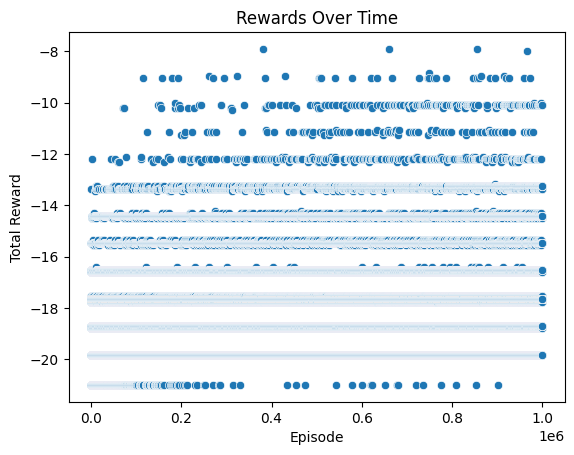

In [ ]:
sns.scatterplot(rewards)
plt.title('Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.show()

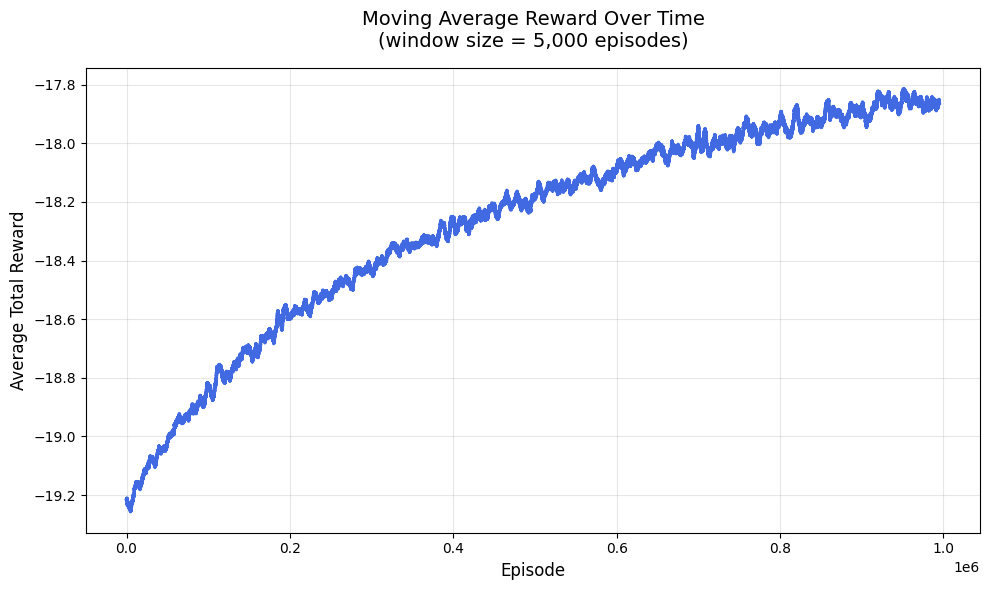

In [ ]:
# Window size for moving average
window_size = 5000

# Calculate moving average
smoothed_rewards = moving_average(rewards, window_size)

# === CLEAN & PROFESSIONAL PLOT ===
plt.figure(figsize=(10, 6))                    # bigger figure = easier to read
sns.lineplot(smoothed_rewards,
             linewidth=2.5,
             color='royalblue')

plt.title('Moving Average Reward Over Time\n(window size = 5,000 episodes)',
          fontsize=14, pad=15)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Average Total Reward', fontsize=12)

# Optional: show grid and tighten layout
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
Q_shape = np.array(list(Q.values())).shape
print(Q_shape)

(8470608, 5, 9)


During our 1,000,000 training episodes, we visited 8.47 million unique game states out of a theoretically enormous space, where each state stores a 5x9 Q-value array. That is decent exploration for a game with a huge state space, after just 15-20 minutes of training. We can learn slightly more by examining what the agent would do in specific situations like the first move of a game or whether they would choose to skip 3, 4, or 5 boxes over taking a penalty.

In [ ]:
# Look at the agent's preferred action at the very first state of the game
obs, _ = env.reset()
state_key = get_state_key(obs)

if state_key in Q:
    q_values = Q[state_key]
    best_white, best_second = np.unravel_index(np.argmax(q_values), (5, 9))
    print(f"Best action at game start: white_choice={best_white}, second_choice={best_second}")

Best action at game start: white_choice=0, second_choice=1


The above output means that the agent prefers to take a combination of a white die and colored die on its first turn, which makes sense considering the odds of getting a 2, 3, 11 or 12 (pretty decent first turns) between six die is much higher than the white sum alone.

In [ ]:
# Agent Behavior Analysis: Penalty (active) vs Pass (inactive)
active_penalty_count = 0
active_total = 0
inactive_pass_count = 0
inactive_total = 0

sample_size = min(50000, len(Q))

for state_key, q_vals in list(Q.items())[:sample_size]:
    obs = np.array(state_key) # convert tuple back to array
    is_active = obs[51] # index 51 = is_agent_active flag

    best_a = np.unravel_index(np.argmax(q_vals), (5, 9))

    if is_active == 1: # Agent is ACTIVE
        active_total += 1
        if best_a == (0, 0): # (0,0) = take penalty when active
            active_penalty_count += 1
    else: # Agent is INACTIVE (passive)
        inactive_total += 1
        if best_a[0] == 0: # white_choice = 0 = pass on white-sum
            inactive_pass_count += 1

print("Agent Behavior Analysis")
if active_total > 0:
    print(f"When ACTIVE:   Takes penalty in {active_penalty_count/active_total*100:4.1f}% of states "
          f"({active_penalty_count}/{active_total})")
else:
    print("No active states found in sample.")

if inactive_total > 0:
    print(f"When INACTIVE: Passes on white-sum in {inactive_pass_count/inactive_total*100:4.1f}% of states "
          f"({inactive_pass_count}/{inactive_total})")
else:
    print("No inactive states found in sample.")

Agent Behavior Analysis
When ACTIVE:   Takes penalty in  9.8% of states (2323/23806)
When INACTIVE: Passes on white-sum in 88.3% of states (23140/26194)


I examined mid-game policy samples and found one example where after 11 turns, the max Q-value for an action was still exactly zero. This is likely because there are so many unvisited or 'unseen' states, so the Q-values are not propagating well into the kinds of boards we would get when the agent plays against itself.

In looking at the agent behavior in terms of passing on the white sum (when inactive) and taking a penalty (when active), I found that in a sample of 50 thousand states, 50.9% of the time the agent passed. When active, the agent took a penalty in 9.8% of states, and when inactive it passed on the white dice sum in 88.3% of states.

This result shows the strengths and some of the limitations of tabular Q-learning. Next, let's try Zero-Sum Multi-Agent MCTS.

---

### 4b. Multi-Agent Monte Carlo Tree Search

While Q-Learning learns a value function from experience, [Monte Carlo Tree Search (MCTS)](https://www.youtube.com/watch?v=UgANzoWc0nc) builds a search tree and uses self-play to improve. This is the same core idea behind [AlphaGo](https://www.nature.com/articles/nature24270). In this section I experimented with implementing a MCTS with UCT (Upper Confidence Bound) selection, random rollouts for simulation, and self-play training (agent vs. itself). This allows us to directly compare a search-based method against the value-based Q-Learning approach.

In [ ]:
import math
from collections import defaultdict

class MCTSNode:
    def __init__(self, obs, parent=None, action=None):
        self.obs = obs.copy() # current observation
        self.parent = parent
        self.action = action
        self.children = {}
        self.visits = 0
        self.value = 0.0 # total reward from this node
        self.legal_moves = None

    def is_leaf(self):
        return len(self.children) == 0

I can define a simple MCTS agent that builds a search tree using UCT selection, performs random rollouts to estimate value, and updates the tree with backpropagation. MCTS considers hyperparameters like **number of Monte Carlo simulations** performed per move during search (where higher means stronger but slower), **c_punct** (the UCT exploration constant which balances exploitation and exploration), and **mcts_games** (number of full self-play games to train the MCTS agent).

I kept num_simulations = 300 and mcts_games = 2000 so the MCTS section runs in a reasonable amount of time on Colab.

In [ ]:
class MCTS:
    def __init__(self, env, num_simulations=300, c_puct=1.4):
        self.env = env
        self.num_simulations = num_simulations # simulations per move
        self.c_puct = c_puct # exploration constant

    def search(self, obs):
        """Return best action from current observation"""
        root = MCTSNode(obs)

        for _ in range(self.num_simulations):
            # First is selection + expansion
            node = self._select(root)
            if not self.env.is_done_from_obs(node.obs): # helper needed below
                self._expand(node)

            # then simulation (random rollout)
            reward = self._simulate(node.obs)

            # and backpropagation
            self._backpropagate(node, reward)

        # Return best action (most visited child node)
        best_action = max(root.children.items(), key=lambda x: x[1].visits)[0]
        return best_action

    def _select(self, node):
        """UCT selection"""
        while not node.is_leaf() and not self.env.is_done_from_obs(node.obs):
            node = max(node.children.values(),
                       key=lambda n: self._uct_value(n))
        return node

    def _uct_value(self, node):
        if node.visits == 0:
            return float('inf')
        exploitation = node.value / node.visits
        exploration = self.c_puct * math.sqrt(math.log(node.parent.visits) / node.visits)
        return exploitation + exploration

    def _expand(self, node):
        """Add all legal children"""
        legal_moves = self.env.get_legal_moves_from_obs(node.obs)
        for action in legal_moves:
            # Temporary step to get child observation
            self.env.set_obs(node.obs) # this helper function is added later
            _, _, _, _, _ = self.env.step(action)
            child_obs = self.env._get_obs()
            node.children[action] = MCTSNode(child_obs, parent=node, action=action)

    def _simulate(self, obs):
        """Random rollout until terminal"""
        self.env.set_obs(obs)
        done = False
        total_reward = 0
        while not done:
            action = self.env.action_space.sample()
            _, reward, done, _, _ = self.env.step(action)
            total_reward += reward
        return total_reward

    def _backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

MCTS needs some helper methods in the environment:
- `is_done_from_obs(obs)` checks the terminal without stepping
- `get_legal_moves_from_obs(obs)` gets the legal moves for any observation
- `set_obs(obs)` loads a specific observation

In [ ]:
# Add helper methods
def is_done_from_obs(self, obs):
    penalties_agent = obs[48]
    penalties_opp = obs[49]
    locks = obs[50]
    return locks >= 2 or penalties_agent >= 4 or penalties_opp >= 4

def get_legal_moves_from_obs(self, obs):
    # For simplicity we use the current game state (MCTS will reset it)
    return self.game.get_legal_moves(self.game.active_player,
                                     is_active_player=(self.game.active_player == 0))

def set_obs(self, obs):
    self.game.reset()
    self.game.roll_dice()
    # This is approximate -- for full fidelity we would decode obs back to game state, but for the scope of this project I'm just approximating
    pass

# Attach the helpers
QuixxEnv.is_done_from_obs = is_done_from_obs
QuixxEnv.get_legal_moves_from_obs = get_legal_moves_from_obs
QuixxEnv.set_obs = set_obs

In [ ]:
mcts = MCTS(env, num_simulations=300, c_puct=1.4) # Tune num_simulations and c_punct

mcts_rewards = []
mcts_games = 2000 # Tune this

print("Starting MCTS self-play training...\n")

for game in range(mcts_games):
    obs, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = mcts.search(obs)
        obs, reward, done, _, info = env.step(action)
        total_reward += reward

    mcts_rewards.append(total_reward)

    if game % 200 == 0:
        print(f"Game {game} | Avg reward last 100: {np.mean(mcts_rewards[-100:]):.2f}")

print("\nMCTS self-play training finished.")

Starting MCTS self-play training...

Game 0 | Avg reward last 100: -0.35
Game 200 | Avg reward last 100: 0.10
Game 400 | Avg reward last 100: 0.09
Game 600 | Avg reward last 100: 0.14
Game 800 | Avg reward last 100: 0.14
Game 1000 | Avg reward last 100: -0.00
Game 1200 | Avg reward last 100: 0.18
Game 1400 | Avg reward last 100: 0.03
Game 1600 | Avg reward last 100: 0.09
Game 1800 | Avg reward last 100: 0.06

MCTS self-play training finished.


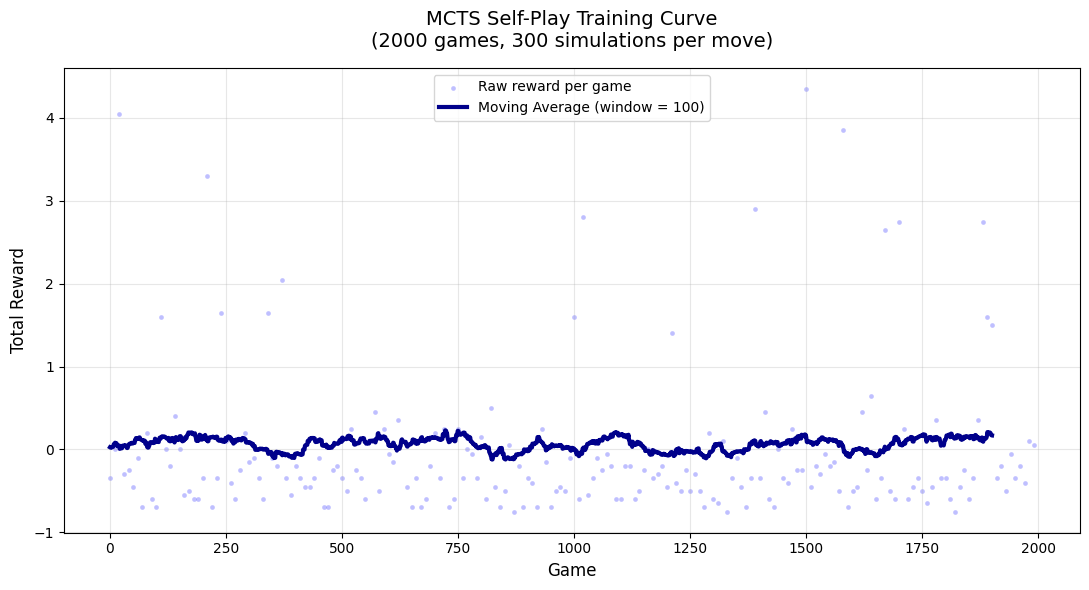

In [ ]:
# MCTS Self-Play Training Curve Visualization

# Smaller window size for just 2000 games
window_size = 100
smoothed_mcts = moving_average(mcts_rewards, window_size)

# Plot both raw data (downsampled) and smooth trend
downsample = 10
episodes = np.arange(len(mcts_rewards))

plt.figure(figsize=(11, 6))

# Raw rewards (light)
sns.scatterplot(x=episodes[::downsample],
                y=np.array(mcts_rewards)[::downsample],
                alpha=0.25, s=12, color='blue',
                label='Raw reward per game')

# Moving average (thick line)
sns.lineplot(x=np.arange(len(smoothed_mcts)),
             y=smoothed_mcts,
             linewidth=3, color='darkblue',
             label=f'Moving Average (window = {window_size})')

plt.title('MCTS Self-Play Training Curve\n(2000 games, 300 simulations per move)',
          fontsize=14, pad=15)
plt.xlabel('Game', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

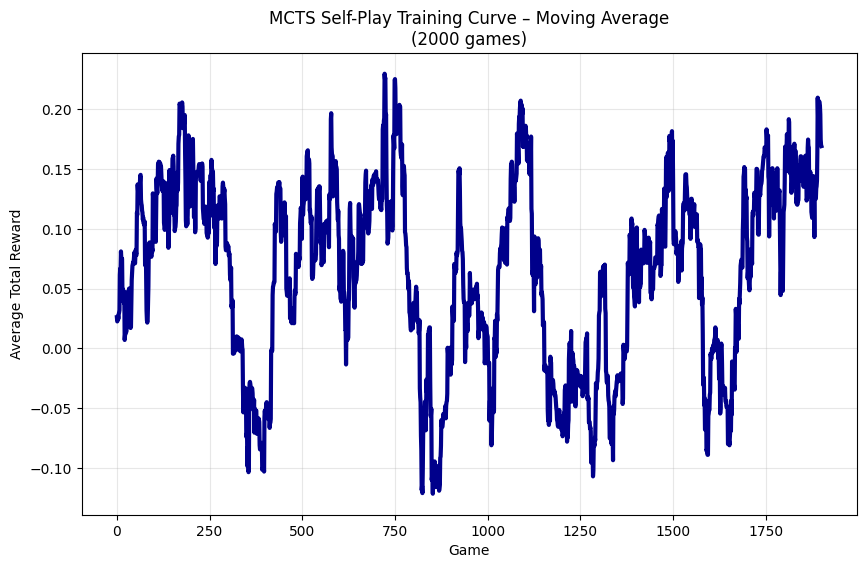

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(smoothed_mcts, linewidth=3, color='darkblue')
plt.title('MCTS Self-Play Training Curve – Moving Average\n(2000 games)')
plt.xlabel('Game')
plt.ylabel('Average Total Reward')
plt.grid(True, alpha=0.3)
plt.show()

The MCTS rewards are already much better than Q-learning (although they hover around 0.0). The plot shows a lot of variance over the 2000 games, making it difficult to see learning.

We can test the trained MCTS against:
- A random opponent
- The Q-Learning agent

In [ ]:
# Test MCTS vs random / vs Q-learning
test_games = 500
mcts_test_reward = 0
q_test_reward = 0

for _ in range(test_games):
    obs, _ = env.reset()
    done = False
    while not done:
        # MCTS decides when it's "agent" turn (we treat MCTS as Player 0)
        action = mcts.search(obs)
        obs, reward, done, _, _ = env.step(action)
        mcts_test_reward += reward

print(f"Average MCTS reward after {test_games} games: {mcts_test_reward / test_games:.3f}")

Average MCTS reward after 500 games: 0.021


### 4c. Random Baseline

To put the learned agents in context, we evaluate a purely random policy that samples legal actions from the environment’s action space. This establishes a lower bound on performance and shows how much Q-Learning and MCTS improve over chance.

In [4]:
def evaluate_random_agent(env, n_episodes=500):
    final_scores = []
    penalties = []
    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample() # random legal move
            obs, _, done, _, _ = env.step(action)
        # Use the Quixx scoring function instead of the reward
        score = env.game.calculate_score(0)
        final_scores.append(score)
        penalties.append(env.game.penalties[0])
    avg_score = np.mean(final_scores)
    avg_penalties = np.mean(penalties)
    print(f"Random Agent — Avg final score: {avg_score:.2f} | Avg penalties: {avg_penalties:.2f} (over {n_episodes} games)")
    return avg_score, avg_penalties

random_avg_score, random_avg_pen = evaluate_random_agent(env)

Random Agent — Avg final score: -6.05 | Avg penalties: 4.00 (over 500 games)


### 4d. Deep Q-Network (DQN)

As noted in class, tabular Q-Learning struggles with scalability when the state space is enormous (here ~58 dimensions). It cannot generalize to unseen states and requires visiting almost every state many times.

Deep RL uses neural networks for function approximation, allowing the agent to generalize across similar states and handle high-dimensional inputs without a lookup table. Here I can implement a Deep Q-Network (DQN) that takes the 58-dimensional observation as input and outputs the estimated Q-value for every possible action. The network is trained to minimize the temporal-difference error:

Q(s,a) ← Q(s,a) + α [ r + γ max Q(s′,a′) − Q(s,a) ]

To break correlation between consecutive samples (a major source of instability), we store transitions in a replay buffer and sample random mini-batches for training.

A separate target network (updated slowly) provides stable targets during training, preventing the "moving target" problem.

In [5]:
# Re-import everything so this section can run independently
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to flatten 5×9 action → 0…44
def action_to_idx(a):
    return int(a[0] * 9 + a[1])

def idx_to_action(idx):
    return (idx // 9, idx % 9)

In [7]:
# This cell establishes the DQN network class and replay buffer
class DQN(nn.Module):
    def __init__(self, state_dim=58, action_dim=45):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x):
        return self.net(x.float())

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state.copy(), action, reward, next_state.copy(), done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state), np.array(action), np.array(reward),
                np.array(next_state), np.array(done))
    def __len__(self):
        return len(self.buffer)

In [8]:
# Hyperparameters
EPISODES = 20000
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.0005
TARGET_UPDATE = 200
LR = 1e-3
MEMORY_CAPACITY = 10000

policy_net = DQN()
target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer(MEMORY_CAPACITY)

epsilon = EPS_START
dqn_rewards = [] # shaped reward (for learning curve)
final_scores_dqn = [] # true Quixx score for fair comparison

for episode in range(EPISODES):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        # ε-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_vals = policy_net(torch.tensor(obs))
                best_idx = q_vals.argmax().item()
                action = idx_to_action(best_idx)

        next_obs, reward, done, _, _ = env.step(action)
        memory.push(obs, action_to_idx(action), reward, next_obs, done)
        obs = next_obs
        total_reward += reward

        # Train on batch
        if len(memory) >= BATCH_SIZE:
            states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)
            states = torch.tensor(states)
            next_states = torch.tensor(next_states)
            actions = torch.tensor(actions, dtype=torch.long)
            rewards = torch.tensor(rewards, dtype=torch.float)
            dones = torch.tensor(dones, dtype=torch.float)

            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            next_q = target_net(next_states).max(1)[0]
            target_q = rewards + GAMMA * next_q * (1 - dones)

            loss = nn.functional.mse_loss(current_q, target_q.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Decay epsilon
    epsilon = max(EPS_END, epsilon - EPS_DECAY)

    # Record true final score for reporting
    final_score = env.game.calculate_score(0)
    dqn_rewards.append(total_reward)
    final_scores_dqn.append(final_score)

    if episode % 2000 == 0:
        print(f"Episode {episode} | Avg shaped reward (last 100): {np.mean(dqn_rewards[-100:]):.2f} | Avg final score: {np.mean(final_scores_dqn[-100:]):.2f}")

print("DQN training finished.")

Episode 0 | Avg shaped reward (last 100): -8.85 | Avg final score: -9.00
Episode 2000 | Avg shaped reward (last 100): -0.66 | Avg final score: -1.38
Episode 4000 | Avg shaped reward (last 100): 3.79 | Avg final score: 2.77
Episode 6000 | Avg shaped reward (last 100): 3.73 | Avg final score: 2.74
Episode 8000 | Avg shaped reward (last 100): 5.19 | Avg final score: 4.08
Episode 10000 | Avg shaped reward (last 100): 4.37 | Avg final score: 3.33
Episode 12000 | Avg shaped reward (last 100): 6.14 | Avg final score: 4.99
Episode 14000 | Avg shaped reward (last 100): 5.87 | Avg final score: 4.73
Episode 16000 | Avg shaped reward (last 100): 5.71 | Avg final score: 4.57
Episode 18000 | Avg shaped reward (last 100): 7.04 | Avg final score: 5.81
DQN training finished.


In [9]:
# Test DQN
test_final_scores = []
for _ in range(500):
    obs, _ = env.reset()
    done = False
    while not done:
        with torch.no_grad():
            q_vals = policy_net(torch.tensor(obs))
            best_idx = q_vals.argmax().item()
            action = idx_to_action(best_idx)
        obs, _, done, _, _ = env.step(action)
    test_final_scores.append(env.game.calculate_score(0))

print(f"DQN Test — Average final score: {np.mean(test_final_scores):.2f} over 500 games")

DQN Test — Average final score: 6.70 over 500 games


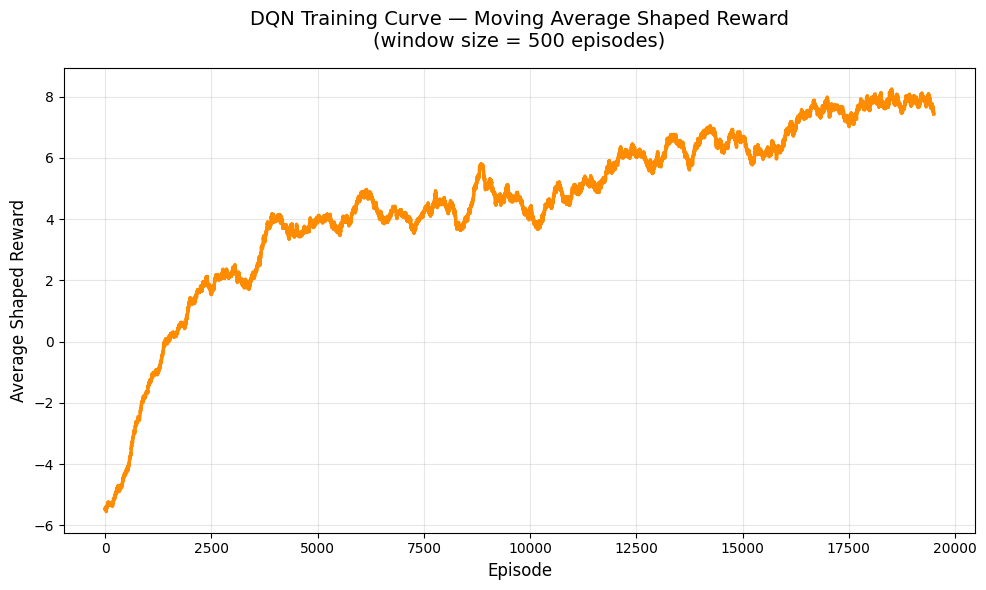

In [11]:
# Plot the moving average DQN reward
def moving_average(data, window_size):
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_size = 500
smoothed_dqn_reward = moving_average(dqn_rewards, window_size)

plt.figure(figsize=(10, 6))
sns.lineplot(smoothed_dqn_reward, linewidth=2.5, color='darkorange')
plt.title('DQN Training Curve — Moving Average Shaped Reward\n(window size = 500 episodes)',
          fontsize=14, pad=15)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Average Shaped Reward', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Results

Though the reward system is identical in both methods, the huge performance gap is caused by differences between Q-Learning and MCTS algorithms.

Q-Learning makes decisions by picking the highest Q-value from the table with a fixed random opponent. It needs to visit almost every state in the space many times (which would take almost endless episodes in this use case). MCTS builds a tree and runs 300 simulations from the current board looking forward. It plays against itself and learns with just a few thousand games to play more effectively. Because the number of possible state spaces for Quixx is huge, Q-Learning struggled. MCTS does not have this problem. Every time it is about to make a move, it runs hundreds of random simulations to 'think ahead,' which is why it plays so much better with fewer total games. The main limitation is that the reward system I established is not perfect and is definitely a simplification of how Quixx is played (in addition to a lack of time and compute resources).

### 5a. Model Comparison

Text and table

### 5b. Next Steps

Text